# Schema-to-Semantic Context Bridge

**MVP**: Ingest database schemas → Generate structured semantic context → Feed to AI agents

Built with:
- **LangChain** `SQLDatabase` + `@tool` for schema introspection
- **LangGraph** `StateGraph` for the pipeline
- **LangChain** `create_agent` for the semantic-aware agent

**Domain**: Financial Services (Trading & Risk)

**API**: NVIDIA NIM (OpenAI-compatible endpoint)

## 1. Setup

In [1]:
!pip install langchain langchain-openai langchain-community langgraph pydantic python-dotenv


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import json
import re
import sqlite3
from typing import Optional, Annotated
from operator import add

from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

from dotenv import load_dotenv
load_dotenv("/Users/akash/KG_Projects/Polanyi Works-Spec/.env")

NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY")

# Pipeline LLM: fast model for structured output generation
PIPELINE_MODEL = "meta/llama-3.1-8b-instruct"

# Agent LLM: larger model for tool-calling agent (if available)
AGENT_MODEL = "nvidia/llama-3.3-nemotron-super-49b-v1.5"

pipeline_llm = ChatOpenAI(
    model=PIPELINE_MODEL,
    api_key=NVIDIA_API_KEY,
    base_url="https://integrate.api.nvidia.com/v1",
    temperature=0,
)

agent_llm = ChatOpenAI(
    model=AGENT_MODEL,
    api_key=NVIDIA_API_KEY,
    base_url="https://integrate.api.nvidia.com/v1",
    temperature=0,
    timeout=120,
    max_retries=2,
)

print(f"Pipeline LLM: {PIPELINE_MODEL}")
print(f"Agent LLM: {AGENT_MODEL}")

/var/folders/s7/zlhm8_cx02gf16jsdq8nj3yr0000gn/T/ipykernel_5189/3122314480.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


Pipeline LLM: meta/llama-3.1-8b-instruct
Agent LLM: nvidia/llama-3.3-nemotron-super-49b-v1.5


## 2. Create Dummy SQLite Database

We build a real SQLite DB from our DDL so `SQLDatabase` can introspect it properly.

In [3]:
DB_PATH = "financial_demo.db"

DDL = """
CREATE TABLE IF NOT EXISTS trades (
    trade_id        INTEGER PRIMARY KEY AUTOINCREMENT,
    trade_date      TIMESTAMP NOT NULL,
    settlement_date TIMESTAMP NOT NULL,
    counterparty_id INTEGER REFERENCES counterparties(counterparty_id),
    instrument_id   INTEGER REFERENCES instruments(instrument_id),
    trade_type      VARCHAR(20) NOT NULL,
    quantity        DECIMAL(18,4) NOT NULL,
    price           DECIMAL(18,6) NOT NULL,
    notional_amount DECIMAL(18,2) NOT NULL,
    currency        VARCHAR(3) DEFAULT 'USD',
    status          VARCHAR(20) DEFAULT 'EXECUTED'
);

CREATE TABLE IF NOT EXISTS counterparties (
    counterparty_id   INTEGER PRIMARY KEY AUTOINCREMENT,
    legal_name        VARCHAR(200) NOT NULL,
    short_name        VARCHAR(50),
    country           VARCHAR(3),
    risk_rating       VARCHAR(10),
    is_sanctioned     BOOLEAN DEFAULT 0,
    sector            VARCHAR(50)
);

CREATE TABLE IF NOT EXISTS instruments (
    instrument_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    isin              VARCHAR(12),
    cusip             VARCHAR(9),
    symbol            VARCHAR(10) NOT NULL,
    name              VARCHAR(200) NOT NULL,
    asset_class       VARCHAR(50) NOT NULL,
    issuer            VARCHAR(200),
    maturity_date     DATE,
    coupon_rate       DECIMAL(8,4),
    currency          VARCHAR(3),
    exchange          VARCHAR(20)
);

CREATE TABLE IF NOT EXISTS positions (
    position_id       INTEGER PRIMARY KEY AUTOINCREMENT,
    account_id        INTEGER REFERENCES accounts(account_id),
    instrument_id     INTEGER REFERENCES instruments(instrument_id),
    quantity          DECIMAL(18,4) NOT NULL,
    avg_cost          DECIMAL(18,6) NOT NULL,
    market_value      DECIMAL(18,2),
    unrealized_pnl    DECIMAL(18,2),
    as_of_date        DATE NOT NULL
);

CREATE TABLE IF NOT EXISTS accounts (
    account_id        INTEGER PRIMARY KEY AUTOINCREMENT,
    account_name      VARCHAR(100) NOT NULL,
    account_type      VARCHAR(30),
    base_currency     VARCHAR(3) DEFAULT 'USD',
    inception_date    DATE,
    status            VARCHAR(20) DEFAULT 'ACTIVE'
);

CREATE TABLE IF NOT EXISTS risk_metrics (
    metric_id         INTEGER PRIMARY KEY AUTOINCREMENT,
    position_id       INTEGER REFERENCES positions(position_id),
    metric_date       DATE NOT NULL,
    var_95            DECIMAL(18,2),
    var_99            DECIMAL(18,2),
    cvar              DECIMAL(18,2),
    sharpe_ratio      DECIMAL(8,4),
    max_drawdown      DECIMAL(8,4),
    volatility        DECIMAL(8,4)
);

CREATE TABLE IF NOT EXISTS daily_pnl (
    trade_date        DATE NOT NULL,
    desk              VARCHAR(50),
    strategy          VARCHAR(100),
    realized_pnl      DECIMAL(18,2),
    unrealized_pnl    DECIMAL(18,2),
    total_pnl         DECIMAL(18,2),
    trade_count       INTEGER,
    notional_traded   DECIMAL(18,2)
);
"""

# Create and populate the DB
con = sqlite3.connect(DB_PATH)
con.executescript(DDL)

# Insert sample data
con.executescript("""
INSERT INTO counterparties (legal_name, short_name, country, risk_rating, is_sanctioned, sector)
VALUES
  ('Goldman Sachs Group Inc', 'GS', 'US', 'AA', 0, 'Financial Services'),
  ('Morgan Stanley', 'MS', 'US', 'AA', 0, 'Financial Services'),
  ('Deutsche Bank AG', 'DB', 'DE', 'BBB', 0, 'Banking'),
  ('Bank of China', 'BOC', 'CN', 'A', 0, 'Banking'),
  ('National Bank of Iran', 'NBI', 'IR', 'CCC', 1, 'Banking');

INSERT INTO instruments (isin, cusip, symbol, name, asset_class, issuer, currency, exchange)
VALUES
  ('US0378331005', '037833100', 'AAPL', 'Apple Inc.', 'EQUITY', 'Apple Inc.', 'USD', 'NASDAQ'),
  ('US5949181045', '594918104', 'MSFT', 'Microsoft Corp', 'EQUITY', 'Microsoft Corp', 'USD', 'NASDAQ'),
  ('US9128285Y80', '9128285Y8', 'UST_10Y', 'US Treasury 10Y', 'FIXED_INCOME', 'US Treasury', 'USD', 'OTC');

INSERT INTO accounts (account_name, account_type, base_currency, status)
VALUES
  ('Prop Trading Fund A', 'TRADING', 'USD', 'ACTIVE'),
  ('Client Fund B', 'TRADING', 'USD', 'ACTIVE');

INSERT INTO trades (trade_date, settlement_date, counterparty_id, instrument_id, trade_type, quantity, price, notional_amount, currency, status)
VALUES
  ('2026-01-15', '2026-01-17', 1, 1, 'BUY', 1000, 185.50, 185500.00, 'USD', 'EXECUTED'),
  ('2026-01-16', '2026-01-18', 2, 2, 'BUY', 500, 420.00, 210000.00, 'USD', 'EXECUTED'),
  ('2026-01-17', '2026-01-19', 1, 3, 'BUY', 1000000, 98.50, 98500000.00, 'USD', 'EXECUTED'),
  ('2026-01-20', '2026-01-22', 5, 1, 'SELL', 200, 190.00, 38000.00, 'USD', 'EXECUTED');

INSERT INTO positions (account_id, instrument_id, quantity, avg_cost, market_value, unrealized_pnl, as_of_date)
VALUES
  (1, 1, 1000, 185.50, 190000.00, 4500.00, '2026-07-15'),
  (1, 2, 500, 420.00, 450000.00, 15000.00, '2026-07-15'),
  (2, 3, 1000000, 98.50, 99000000.00, 500000.00, '2026-07-15');

INSERT INTO risk_metrics (position_id, metric_date, var_95, var_99, cvar, sharpe_ratio, max_drawdown, volatility)
VALUES
  (1, '2026-07-15', 45000.00, 72000.00, 85000.00, 1.25, 0.08, 0.22),
  (2, '2026-07-15', 120000.00, 195000.00, 230000.00, 1.45, 0.06, 0.18),
  (3, '2026-07-15', 1500000.00, 2400000.00, 2800000.00, 0.85, 0.04, 0.12);

INSERT INTO daily_pnl (trade_date, desk, strategy, realized_pnl, unrealized_pnl, total_pnl, trade_count, notional_traded)
VALUES
  ('2026-07-15', 'Rates', 'Duration Roll', 125000.00, -45000.00, 80000.00, 12, 50000000.00),
  ('2026-07-15', 'Credit', 'CDS Basis', 85000.00, 22000.00, 107000.00, 8, 25000000.00),
  ('2026-07-15', 'FX', 'G10 Carry', -15000.00, 8000.00, -7000.00, 20, 10000000.00);
""")
con.close()

print(f"Created {DB_PATH} with sample data")

Created financial_demo.db with sample data


## 3. SQLDatabase + Schema Introspection (langchain_community)

In [4]:
db = SQLDatabase.from_uri(f"sqlite:///{DB_PATH}")

print("Dialect:", db.dialect)
print("Tables:", db.get_usable_table_names())
print()
print("Full schema:")
print(db.get_table_info())

Dialect: sqlite
Tables: ['accounts', 'counterparties', 'daily_pnl', 'instruments', 'positions', 'risk_metrics', 'trades']

Full schema:

CREATE TABLE accounts (
	account_id INTEGER, 
	account_name VARCHAR(100) NOT NULL, 
	account_type VARCHAR(30), 
	base_currency VARCHAR(3) DEFAULT 'USD', 
	inception_date DATE, 
	status VARCHAR(20) DEFAULT 'ACTIVE', 
	PRIMARY KEY (account_id)
)

/*
3 rows from accounts table:
account_id	account_name	account_type	base_currency	inception_date	status
1	Prop Trading Fund A	TRADING	USD	None	ACTIVE
2	Client Fund B	TRADING	USD	None	ACTIVE
*/


CREATE TABLE counterparties (
	counterparty_id INTEGER, 
	legal_name VARCHAR(200) NOT NULL, 
	short_name VARCHAR(50), 
	country VARCHAR(3), 
	risk_rating VARCHAR(10), 
	is_sanctioned BOOLEAN DEFAULT 0, 
	sector VARCHAR(50), 
	PRIMARY KEY (counterparty_id)
)

/*
3 rows from counterparties table:
counterparty_id	legal_name	short_name	country	risk_rating	is_sanctioned	sector
1	Goldman Sachs Group Inc	GS	US	AA	False	Financi

## 4. Pydantic Models — Structured Output Schemas

In [5]:
class GlossaryEntry(BaseModel):
    term: str = Field(description="Business term (e.g., 'Notional Amount')")
    definition: str = Field(description="Clear business definition")
    formula: Optional[str] = Field(default=None, description="Formula if applicable")
    source_tables: list[str] = Field(description="Which tables contain this data")
    source_columns: list[str] = Field(description="Specific columns")
    unit: Optional[str] = Field(default=None, description="Unit of measurement")
    synonyms: list[str] = Field(default_factory=list, description="Alternative names")


class EntityRelationship(BaseModel):
    from_entity: str = Field(description="Source table/entity")
    to_entity: str = Field(description="Target table/entity")
    relationship_type: str = Field(description="one-to-many, many-to-one, many-to-many")
    foreign_key: str = Field(description="The joining column(s)")
    description: str = Field(description="Business meaning of this relationship")


class BusinessRuleContext(BaseModel):
    rule_id: str
    name: str
    description: str
    sql_hints: list[str] = Field(description="SQL patterns that satisfy or violate this rule")
    affected_entities: list[str] = Field(description="Entities this rule applies to")
    severity: str


class SemanticContext(BaseModel):
    """Complete semantic context for an AI agent."""
    domain: str = Field(description="Business domain")
    glossary: list[GlossaryEntry] = Field(description="Business glossary")
    relationships: list[EntityRelationship] = Field(description="Entity relationships")
    business_rules: list[BusinessRuleContext] = Field(description="Business rules with SQL hints")
    key_entities: list[str] = Field(description="Main entities for query planning")
    common_queries: list[str] = Field(description="Frequently asked questions")

## 5. LangGraph State — Pipeline Data Structure

In [6]:
class PipelineState(BaseModel):
    """State flowing through the LangGraph pipeline."""
    # Input
    db_uri: str = ""
    business_rules_raw: list[dict] = Field(default_factory=list)

    # From SQLDatabase introspection
    table_names: list[str] = Field(default_factory=list)
    table_info: str = ""

    # LLM-generated
    semantic_context: Optional[SemanticContext] = None

    # Final output
    agent_prompt: str = ""
    errors: Annotated[list[str], add] = Field(default_factory=list)

## 6. LangGraph Nodes

In [7]:
# ── Node 1: Introspect DB via SQLDatabase ──────────────────────
def introspect_db_node(state: PipelineState) -> dict:
    """Use langchain_community SQLDatabase to extract schema."""
    db = SQLDatabase.from_uri(state.db_uri)
    return {
        "table_names": db.get_usable_table_names(),
        "table_info": db.get_table_info()
    }

In [8]:
import time

# ── Node 2: LLM Generate Semantic Context ─────────────────────
def generate_context_node(state: PipelineState) -> dict:
    """Use LangChain with_structured_output to generate SemanticContext."""
    structured_llm = pipeline_llm.with_structured_output(SemanticContext)

    rules_text = "\n".join(
        f"[{r['rule_id']}] {r['name']}: {r['description']} (Severity: {r['severity']})"
        for r in state.business_rules_raw
    )

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a financial services data architect.
Given a database schema and business rules, generate a structured semantic context
that an AI agent can use to accurately answer business questions.

The glossary should define key business terms with formulas where applicable.
Relationships should capture how tables connect.
Business rules should include SQL hints showing how to enforce them."""),
        ("human", """Database schema:

{table_info}

Business rules:
{rules}

Generate semantic context. Focus on:
1. Business terms a CFO or risk manager would use
2. How to correctly calculate revenue, exposure, and risk
3. Compliance rules that must be enforced in queries
4. The most important entity relationships""")
    ])

    chain = prompt | structured_llm
    for attempt in range(3):
        try:
            result = chain.invoke({
                "table_info": state.table_info,
                "rules": rules_text
            })
            return {"semantic_context": result}
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            if attempt < 2:
                time.sleep(5)
    raise Exception("Failed after 3 attempts")

In [9]:
# ── Node 3: Build Agent Prompt ────────────────────────────────
def build_prompt_node(state: PipelineState) -> dict:
    """Convert SemanticContext into a system prompt for agents."""
    ctx = state.semantic_context
    lines = [
        f"# Enterprise Semantic Context — {ctx.domain}",
        "",
        "You are an AI assistant for a financial services company.",
        "Use the following business context to answer questions accurately.",
        "NEVER guess definitions. Use ONLY the glossary below.",
        "",
        "## Business Glossary", ""
    ]
    for entry in ctx.glossary:
        lines.append(f"### {entry.term}")
        lines.append(f"Definition: {entry.definition}")
        if entry.formula:
            lines.append(f"Formula: {entry.formula}")
        lines.append(f"Source: {', '.join(entry.source_tables)}")
        if entry.unit:
            lines.append(f"Unit: {entry.unit}")
        lines.append("")

    lines.append("## Entity Relationships")
    lines.append("")
    for rel in ctx.relationships:
        lines.append(f"- {rel.from_entity} --[{rel.relationship_type}]--> {rel.to_entity} (via {rel.foreign_key})")
        lines.append(f"  {rel.description}")
    lines.append("")

    lines.append("## Business Rules (MUST enforce)")
    lines.append("")
    for rule in ctx.business_rules:
        lines.append(f"### [{rule.severity}] {rule.name}")
        lines.append(rule.description)
        if rule.sql_hints:
            lines.append("SQL patterns:")
            for hint in rule.sql_hints:
                lines.append(f"  {hint}")
        lines.append("")

    lines.append("## Key Entities")
    lines.append(" > ".join(ctx.key_entities))
    lines.append("")
    lines.append("## Common Questions")
    for q in ctx.common_queries:
        lines.append(f"- {q}")

    return {"agent_prompt": "\n".join(lines)}

## 7. Assemble the LangGraph Pipeline

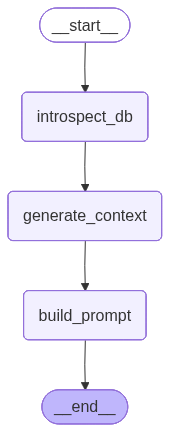

In [10]:
graph = StateGraph(PipelineState)

graph.add_node("introspect_db", introspect_db_node)
graph.add_node("generate_context", generate_context_node)
graph.add_node("build_prompt", build_prompt_node)

graph.add_edge(START, "introspect_db")
graph.add_edge("introspect_db", "generate_context")
graph.add_edge("generate_context", "build_prompt")
graph.add_edge("build_prompt", END)

pipeline = graph.compile()

from IPython.display import Image, display
display(Image(pipeline.get_graph().draw_mermaid_png()))

## 8. Run the Pipeline

In [11]:
BUSINESS_RULES = [
    {"rule_id": "BR-001", "name": "Sanctioned Counterparty Check",
     "description": "No trade may be executed with a counterparty where is_sanctioned = TRUE",
     "tables": ["counterparties", "trades"], "severity": "CRITICAL"},
    {"rule_id": "BR-002", "name": "Settlement Date Validation",
     "description": "Settlement date must be >= trade_date (T+1 or later)",
     "tables": ["trades"], "severity": "HIGH"},
    {"rule_id": "BR-003", "name": "VaR Threshold Alert",
     "description": "If var_95 > 1000000, flag position for review",
     "tables": ["risk_metrics"], "severity": "MEDIUM"},
    {"rule_id": "BR-004", "name": "Revenue Definition",
     "description": "Revenue = SUM(total_pnl) where status = 'EXECUTED' and trade_date >= fiscal_year_start",
     "tables": ["trades"], "severity": "INFO"},
    {"rule_id": "BR-005", "name": "High-Risk Country Exposure",
     "description": "If counterparty.country IN ('IR','KP','SY','CU') and notional_amount > 500000, require EDD",
     "tables": ["counterparties", "trades"], "severity": "CRITICAL"}
]

result = pipeline.invoke({
    "db_uri": f"sqlite:///{DB_PATH}",
    "business_rules_raw": BUSINESS_RULES,
})

print("Tables:", result["table_names"])
print("Glossary entries:", len(result["semantic_context"].glossary))
print("Relationships:", len(result["semantic_context"].relationships))
print("Business rules:", len(result["semantic_context"].business_rules))

Tables: ['accounts', 'counterparties', 'daily_pnl', 'instruments', 'positions', 'risk_metrics', 'trades']
Glossary entries: 5
Relationships: 4
Business rules: 5


In [12]:
# Inspect full semantic context
result["semantic_context"].model_dump_json(indent=2)

'{\n  "domain": "Financial Services",\n  "glossary": [\n    {\n      "term": "Sanctioned Counterparty",\n      "definition": "A counterparty with is_sanctioned = TRUE",\n      "formula": "SELECT * FROM counterparties WHERE is_sanctioned = TRUE",\n      "source_tables": [\n        "counterparties"\n      ],\n      "source_columns": [\n        "is_sanctioned"\n      ],\n      "unit": "Boolean",\n      "synonyms": [\n        "Blocked Counterparty",\n        "Prohibited Counterparty"\n      ]\n    },\n    {\n      "term": "Settlement Date",\n      "definition": "The date when a trade is settled",\n      "formula": "trade_date + INTERVAL \'1 day\'",\n      "source_tables": [\n        "trades"\n      ],\n      "source_columns": [\n        "trade_date"\n      ],\n      "unit": "Date",\n      "synonyms": [\n        "Trade Settlement Date",\n        "Trade Date Plus One"\n      ]\n    },\n    {\n      "term": "Value-at-Risk (VaR)",\n      "definition": "The maximum potential loss of a portfolio

In [13]:
# Preview agent prompt
print(result["agent_prompt"][:2000])

# Enterprise Semantic Context — Financial Services

You are an AI assistant for a financial services company.
Use the following business context to answer questions accurately.
NEVER guess definitions. Use ONLY the glossary below.

## Business Glossary

### Sanctioned Counterparty
Definition: A counterparty with is_sanctioned = TRUE
Formula: SELECT * FROM counterparties WHERE is_sanctioned = TRUE
Source: counterparties
Unit: Boolean

### Settlement Date
Definition: The date when a trade is settled
Formula: trade_date + INTERVAL '1 day'
Source: trades
Unit: Date

### Value-at-Risk (VaR)
Definition: The maximum potential loss of a portfolio over a given time horizon with a given probability
Formula: SELECT var_95 FROM risk_metrics
Source: risk_metrics
Unit: Currency

### Revenue
Definition: The total profit earned from executed trades
Formula: SELECT SUM(total_pnl) FROM daily_pnl WHERE status = 'EXECUTED' AND trade_date >= fiscal_year_start
Source: daily_pnl
Unit: Currency

### Exposure


## 9. SQL Agent Tools (langchain_community pattern)

Following the official LangChain SQL agent pattern with `@tool` decorators.

In [14]:
db_for_agent = SQLDatabase.from_uri(f"sqlite:///{DB_PATH}")


@tool
def sql_db_list_tables() -> str:
    """Input is an empty string, output is a comma-separated list of tables in the database."""
    return ", ".join(db_for_agent.get_usable_table_names())


@tool
def sql_db_schema(table_names: str) -> str:
    """Input is a comma-separated list of tables, output is the schema and sample rows.
    Be sure that the tables actually exist by calling sql_db_list_tables first!
    Example Input: table1, table2"""
    results = []
    for table in table_names.split(","):
        table = table.strip()
        if table not in db_for_agent.get_usable_table_names():
            results.append(f"Error: table '{table}' not found")
            continue
        info = db_for_agent.get_table_info([table])
        results.append(info)
    return "\n\n".join(results)


@tool
def sql_db_query(query: str) -> str:
    """Input is a SQL query, output is the result from the database.
    If the query is not correct, an error message will be returned.
    If you encounter an error, use sql_db_schema to check the correct table fields."""
    try:
        result = db_for_agent.run(query)
        return result
    except Exception as e:
        return f"Error: {e}"


@tool
def sql_db_query_checker(query: str) -> str:
    """Use this tool to double check if your query is correct before executing it.
    Always use this tool before executing a query with sql_db_query!"""
    check_prompt = f"""{query}

Double check the SQL query above for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Using the proper columns for joins

If there are any mistakes, rewrite the query. If there are no mistakes, reproduce the original query.
Output the final SQL query only."""
    response = pipeline_llm.invoke(check_prompt)
    return response.content.strip()


sql_tools = [sql_db_list_tables, sql_db_schema, sql_db_query, sql_db_query_checker]

for t in sql_tools:
    print(f"{t.name}: {t.description[:80]}...")

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the data...
sql_db_schema: Input is a comma-separated list of tables, output is the schema and sample rows....
sql_db_query: Input is a SQL query, output is the result from the database.
If the query is no...
sql_db_query_checker: Use this tool to double check if your query is correct before executing it.
Alwa...


## 10. Semantic SQL Agent Demo

Uses `nvidia/llama-3.3-nemotron-super-49b-v1.5` for tool-calling agent.
The semantic context from Section 8 is injected into the system prompt.

In [15]:
from langchain.agents import create_agent

system_prompt = f"""You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct SQLite query to run,
then look at the results and return the answer.

Unless the user specifies a specific number of examples, always limit your
query to at most 5 results.

You MUST double check your query before executing it using sql_db_query_checker.
If you get an error, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.).

ALWAYS look at the tables first using sql_db_list_tables.
Then query the schema of the most relevant tables using sql_db_schema.

{result['agent_prompt']}"""

agent = create_agent(
    model=agent_llm,
    tools=sql_tools,
    system_prompt=system_prompt,
)

print("Agent created with semantic context injected into system prompt")

Agent created with semantic context injected into system prompt


In [16]:
q = "Which counterparties are in high-risk countries?"
print(f"Q: {q}")
print("-" * 60)
result_demo = agent.invoke({"messages": [HumanMessage(content=q)]})
answer = result_demo["messages"][-1].content
print(f"A: {answer}")

Q: Which counterparties are in high-risk countries?
------------------------------------------------------------


A: The query identified the following counterparty in a high-risk country:

**Counterparty:** National Bank of Iran (NBI)  
**Country:** Iran (IR)  
**Risk Rating:** CCC  
**Sanctioned Status:** Sanctioned (is_sanctioned = TRUE)  
**Sector:** Banking  

This counterparty is located in Iran (country code 'IR'), which is classified as a high-risk country according to the business rules. Would you like additional details about this counterparty or further analysis?


## 12. Save Outputs

In [17]:
with open("semantic_context.json", "w") as f:
    json.dump(result["semantic_context"].model_dump(), f, indent=2, default=str)

with open("agent_prompt.txt", "w") as f:
    f.write(result["agent_prompt"])

print("Saved: semantic_context.json, agent_prompt.txt")

Saved: semantic_context.json, agent_prompt.txt


## 13. Next Steps

1. **Add more schema sources**: OpenAPI, MongoDB, Excel
2. **Ontology versioning**: Track glossary drift over time
3. **Symbolic validation**: Validate LLM-generated SQL against business rules before execution
4. **LLM feedback loop**: Update glossary when agent gives wrong answers
5. **Connect to production**: Replace SQLite with real PostgreSQL/Snowflake
6. **Upgrade LLM**: Use OpenAI GPT-4o or Claude for faster, more reliable agent loops